In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [15]:
# import pandas as pd
# import numpy as np
# from datetime import datetime, timedelta

# # Set random seed for reproducibility
# np.random.seed(42)

# # Parameters
# start_date = datetime(2026, 5, 1)
# end_date = datetime(2026, 8, 30)
# features_per_day = 30

# # Generate timestamps (Monday to Friday, 9:00–14:00)
# date_range = pd.date_range(start=start_date, end=end_date, freq='D')
# workdays = [d for d in date_range if d.weekday() < 5]

# timestamps = []
# for day in workdays:
#     for i in range(features_per_day):
#         time = datetime(day.year, day.month, day.day, 9, 0, 0) + timedelta(minutes=10 * i)
#         timestamps.append(time)
# timestamps = pd.to_datetime(timestamps)

# total_features = len(timestamps)

# # Generate mask_ids
# mask_ids = []
# for day in workdays:
#     for writer in ['MBMW_03', 'MBMW_04', 'MBMW_05']:
#         mask_id = f"M_{day.year}_{day.month:02d}_{day.day:02d}_{writer[-2:]}"
#         for _ in range(features_per_day // 3):
#             mask_ids.append(mask_id)
# mask_ids = mask_ids[:total_features]

# # Writer distribution
# writer_ids = []
# for i in range(total_features):
#     if i % 3 == 0:
#         writer_ids.append('MBMW_03')
#     elif i % 3 == 1:
#         writer_ids.append('MBMW_04')
#     else:
#         writer_ids.append('MBMW_05')

# # Positions
# x_positions = np.random.uniform(0, 5000, size=total_features).round(1)
# y_positions = np.random.uniform(0, 5000, size=total_features).round(1)

# center_distances = np.sqrt((x_positions - 2500)**2 + (y_positions - 2500)**2)
# edge_effect = (center_distances / 2500) * 2

# # Target widths
# target_widths = np.random.choice([40.0, 50.0, 60.0, 70.0, 80.0], size=total_features)

# # Exposure dose
# time_factor = np.linspace(0, 1, len(timestamps))
# tool_dose_bias = {'MBMW_03': 0, 'MBMW_04': 0.5, 'MBMW_05': -0.3}

# exposure_doses = 14.0 + 2.0 * time_factor
# for i, writer in enumerate(writer_ids):
#     exposure_doses[i] += tool_dose_bias[writer]

# exposure_doses += np.random.normal(0, 0.3, size=total_features)
# exposure_doses = np.clip(exposure_doses, 11.0, 17.0).round(2)

# # Temperature
# hour_of_day = np.array([ts.hour + ts.minute / 60 for ts in timestamps])
# daily_temp_cycle = 1.5 * np.sin(2 * np.pi * (hour_of_day - 14) / 24)

# temperature = 22.0 + 2.0 * time_factor + daily_temp_cycle + np.random.normal(0, 0.3, size=total_features)
# temperature = np.clip(temperature, 20.0, 26.0).round(1)

# # Humidity
# humidity = 45.0 + 5.0 * np.sin(2 * np.pi * (hour_of_day - 6) / 24) + np.random.normal(0, 2, size=total_features)
# humidity = np.clip(humidity, 35.0, 55.0).round(1)

# # Vibration
# vibration = np.random.uniform(0.01, 0.04, size=total_features)
# for i, writer in enumerate(writer_ids):
#     if writer == 'MBMW_03':
#         vibration[i] += 0.02
#     elif writer == 'MBMW_04':
#         vibration[i] += 0.01

# spike_indices = np.random.choice(total_features, size=int(total_features * 0.01), replace=False)
# vibration[spike_indices] = np.random.uniform(0.08, 0.15, size=len(spike_indices))
# vibration = np.clip(vibration, 0.01, 0.15).round(3)

# # --- Error model components ---
# temp_error = (temperature - 22) * 0.3
# vibration_error = vibration * 20
# position_error = edge_effect * 1.5
# tool_bias = {'MBMW_03': 0, 'MBMW_04': -0.8, 'MBMW_05': 0.5}

# # --- Dose-dependent error (MAIN DRIVER) ---
# dose_center = 14.5

# dose_error_linear = (exposure_doses - dose_center) * 1.8
# dose_error_quadratic = (exposure_doses - dose_center)**2 * 0.4

# dose_error = dose_error_linear + dose_error_quadratic

# # Width-dependent sensitivity (more realistic)
# dose_sensitivity = 0.02 * target_widths
# dose_error *= (1 + dose_sensitivity)

# # Optional saturation (prevents unrealistic extremes)
# dose_error = np.tanh(dose_error / 5) * 5

# # --- Combine errors ---
# errors = np.random.normal(0, 1.2, size=total_features)

# errors += (
#     temp_error * 0.5 +
#     vibration_error * 0.5 +
#     position_error * 0.5 +
#     dose_error
# )

# for i, writer in enumerate(writer_ids):
#     errors[i] += tool_bias[writer]

# # Add outliers
# outlier_indices = np.random.choice(total_features, size=int(total_features * 0.02), replace=False)
# errors[outlier_indices] += np.random.normal(8, 3, size=len(outlier_indices))

# # Final widths
# measured_widths = target_widths + errors
# measured_widths = np.clip(measured_widths, 10.0, 150.0).round(1)

# # CD error
# cd_error = (measured_widths - target_widths).round(2)

# # Defects
# defect_flag = (np.abs(cd_error) > 3).astype(int)

# # Feature IDs
# feature_ids = [f"F_{i:06d}" for i in range(1, total_features + 1)]

# # DataFrame
# df = pd.DataFrame({
#     'feature_id': feature_ids,
#     'timestamp': timestamps,
#     'mask_id': mask_ids,
#     'writer_id': writer_ids,
#     'x_position': x_positions,
#     'y_position': y_positions,
#     'target_width': target_widths,
#     'measured_width': measured_widths,
#     'cd_error': cd_error,
#     'defect_flag': defect_flag,
#     'exposure_dose': exposure_doses,
#     'temperature': temperature,
#     'humidity': humidity,
#     'vibration': vibration
# })

# # Time features
# df['day'] = df['timestamp'].dt.day
# df['week'] = df['timestamp'].dt.isocalendar().week
# df['month'] = df['timestamp'].dt.month
# df['hour'] = df['timestamp'].dt.hour
# df['day_of_week'] = df['timestamp'].dt.dayofweek

# # Save
# df.to_csv("metrology_data.csv", index=False)

# print("Dataset generated successfully!")

Dataset generated successfully!


In [17]:
data = pd.read_csv('metrology_data.csv')
data.head()

,feature_id,timestamp,mask_id,writer_id,x_position,y_position,target_width,measured_width,cd_error,defect_flag,exposure_dose,temperature,humidity,vibration,day,week,month,hour,day_of_week
0,F_000001,2026-05-01 09:00:00,M_2026_05_01_03,MBMW_03,1872.7,614.6,50.0,52.8,2.8,0,13.97,20.2,47.5,0.054,1,18,5,9,4
1,F_000002,2026-05-01 09:10:00,M_2026_05_01_03,MBMW_04,4753.6,4443.3,80.0,78.6,-1.4,0,13.94,20.0,42.0,0.047,1,18,5,9,4
2,F_000003,2026-05-01 09:20:00,M_2026_05_01_03,MBMW_05,3660.0,2515.4,80.0,80.4,0.4,0,14.16,20.7,47.7,0.024,1,18,5,9,4
3,F_000004,2026-05-01 09:30:00,M_2026_05_01_03,MBMW_03,2993.3,2246.7,80.0,77.7,-2.3,0,13.89,20.5,51.1,0.057,1,18,5,9,4
4,F_000005,2026-05-01 09:40:00,M_2026_05_01_03,MBMW_04,780.1,2929.3,80.0,80.2,0.2,0,14.69,20.7,51.9,0.035,1,18,5,9,4


In [18]:
data.shape

(2580, 19)

In [19]:
data.describe()

,x_position,y_position,target_width,measured_width,cd_error,defect_flag,exposure_dose,temperature,humidity,vibration,day,week,month,hour,day_of_week
count,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000
mean,2497.585155,2467.855736,59.647287,63.166550,3.519264,0.584109,15.064818,22.125078,49.587403,0.035571,15.651163,26.895349,6.488372,11.000000,2.023256
std,1456.406345,1436.340708,14.174712,14.468149,2.739082,0.492971,0.723511,0.788446,2.039387,0.014332,8.688439,4.966024,1.097187,1.414488,1.422498
min,7.800000,0.100000,40.000000,36.700000,-3.800000,0.000000,13.150000,20.000000,42.000000,0.010000,1.000000,18.000000,5.000000,9.000000,0.000000
25%,1215.025000,1233.225000,50.000000,51.400000,1.600000,0.000000,14.517500,21.600000,48.200000,0.026000,8.000000,23.000000,6.000000,10.000000,1.000000
50%,2530.050000,2452.200000,60.000000,62.800000,3.700000,1.000000,15.070000,22.100000,49.600000,0.035000,15.500000,27.000000,6.500000,11.000000,2.000000
75%,3758.150000,3705.325000,70.000000,75.300000,5.400000,1.000000,15.600000,22.700000,50.900000,0.043250,23.000000,31.000000,7.000000,12.000000,3.000000
max,4998.600000,4997.800000,80.000000,98.300000,18.900000,1.000000,17.000000,24.500000,55.000000,0.150000,31.000000,35.000000,8.000000,13.000000,4.000000


In [20]:
data.isnull().sum()

feature_id        0
timestamp         0
mask_id           0
writer_id         0
x_position        0
y_position        0
target_width      0
measured_width    0
cd_error          0
defect_flag       0
exposure_dose     0
temperature       0
humidity          0
vibration         0
day               0
week              0
month             0
hour              0
day_of_week       0
dtype: int64

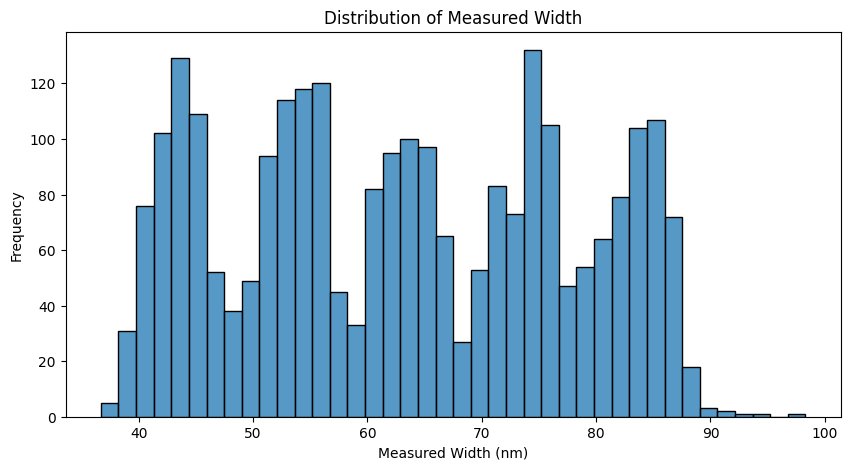

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(data['measured_width'], bins=40)
plt.title('Distribution of Measured Width')
plt.xlabel('Measured Width (nm)')
plt.ylabel('Frequency')
plt.show()

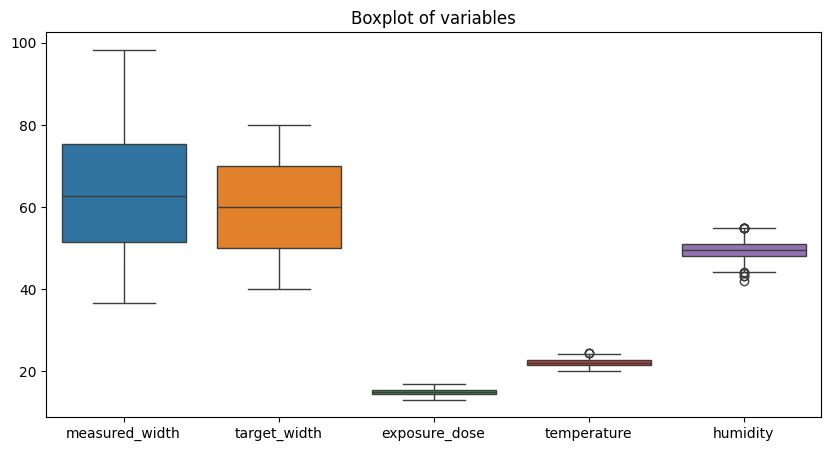

In [22]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data[['measured_width', 'target_width', 'exposure_dose', 'temperature', 'humidity']])
plt.title('Boxplot of variables')
plt.show()

In [23]:
data['measure_error'] = abs(data['measured_width'] - data['target_width'])

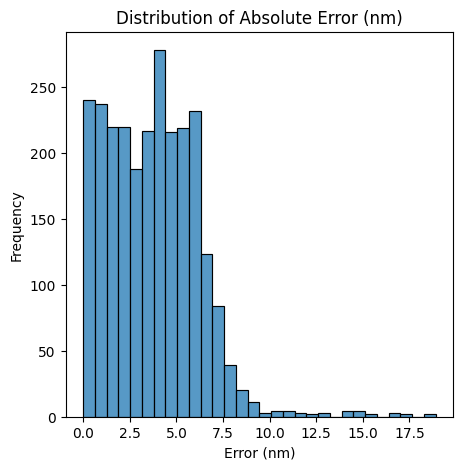

In [24]:
plt.figure(figsize=(5, 5))
sns.histplot(data['measure_error'], bins=30)
plt.title('Distribution of Absolute Error (nm)')
plt.xlabel('Error (nm)')
plt.ylabel('Frequency')
plt.show()

In [25]:
data[data['measure_error'] > 2.5]

,feature_id,timestamp,mask_id,writer_id,x_position,y_position,target_width,measured_width,cd_error,defect_flag,exposure_dose,temperature,humidity,vibration,day,week,month,hour,day_of_week,measure_error
0,F_000001,2026-05-01 09:00:00,M_2026_05_01_03,MBMW_03,1872.7,614.6,50.0,52.8,2.8,0,13.97,20.2,47.5,0.054,1,18,5,9,4,2.8
8,F_000009,2026-05-01 10:20:00,M_2026_05_01_03,MBMW_05,3005.6,1209.7,60.0,56.2,-3.8,1,13.71,20.5,47.9,0.015,1,18,5,10,4,3.8
20,F_000021,2026-05-01 12:20:00,M_2026_05_01_05,MBMW_05,3059.3,3147.8,40.0,37.4,-2.6,0,13.90,21.3,44.7,0.039,1,18,5,12,4,2.6
28,F_000029,2026-05-01 13:40:00,M_2026_05_01_05,MBMW_04,2962.1,3534.9,80.0,85.5,5.5,1,15.35,21.9,48.0,0.049,1,18,5,13,4,5.5
43,F_000044,2026-05-04 11:10:00,M_2026_05_04_04,MBMW_04,4546.6,4549.7,50.0,54.9,4.9,1,14.58,21.1,49.6,0.027,4,19,5,11,0,4.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2575,F_002576,2026-08-28 13:10:00,M_2026_08_28_05,MBMW_04,3202.4,1504.8,60.0,65.2,5.2,1,16.64,23.7,48.6,0.030,28,35,8,13,4,5.2
2576,F_002577,2026-08-28 13:20:00,M_2026_08_28_05,MBMW_05,4894.9,920.2,50.0,56.4,6.4,1,15.26,23.1,50.3,0.026,28,35,8,13,4,6.4
2577,F_002578,2026-08-28 13:30:00,M_2026_08_28_05,MBMW_03,3017.5,3782.3,60.0,66.7,6.7,1,15.73,23.6,50.4,0.035,28,35,8,13,4,6.7
2578,F_002579,2026-08-28 13:40:00,M_2026_08_28_05,MBMW_04,1789.1,2370.8,50.0,54.7,4.7,1,16.87,23.9,50.5,0.038,28,35,8,13,4,4.7


measure_error    1.000000
exposure_dose    0.689342
temperature      0.490187
vibration        0.086380
humidity        -0.003520
Name: measure_error, dtype: float64


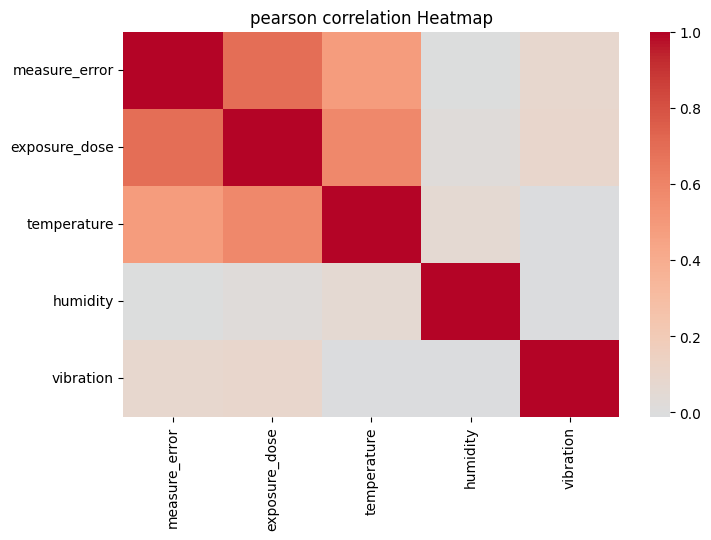

measure_error    1.000000
exposure_dose    0.781512
temperature      0.540780
vibration        0.086449
humidity         0.005135
Name: measure_error, dtype: float64


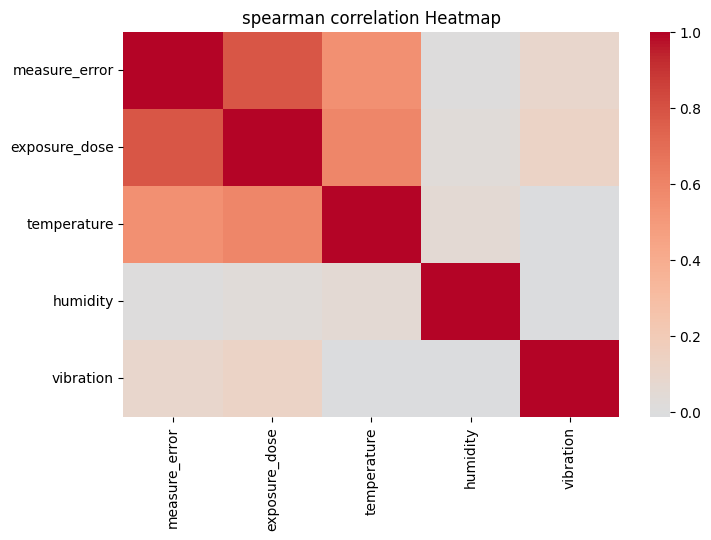

In [26]:
for cor in ['pearson','spearman']:
    correlation = data[['measure_error', 'exposure_dose', 'temperature', 'humidity', 'vibration']].corr(method= cor)
    print(correlation['measure_error'].sort_values(ascending = False))
    plt.figure(figsize=(8, 5))
    sns.heatmap(correlation, cmap='coolwarm', center=0)
    plt.title(f'{cor} correlation Heatmap')
    plt.show()

Slope:  [2.33718115]


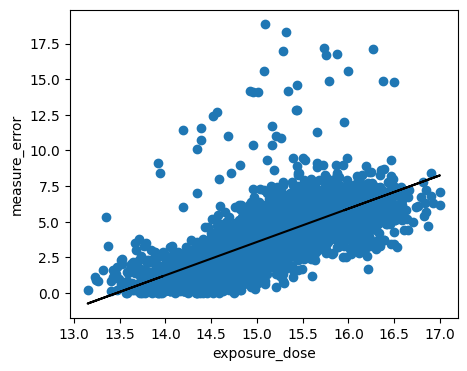

Slope:  [1.52508155]


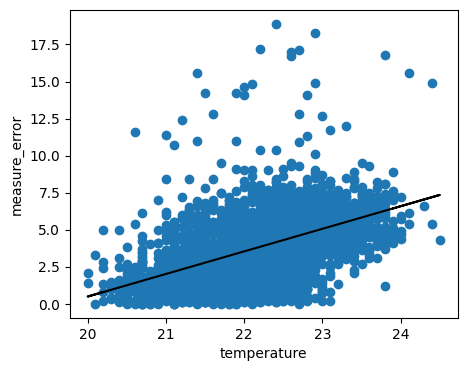

Slope:  [-0.00423376]


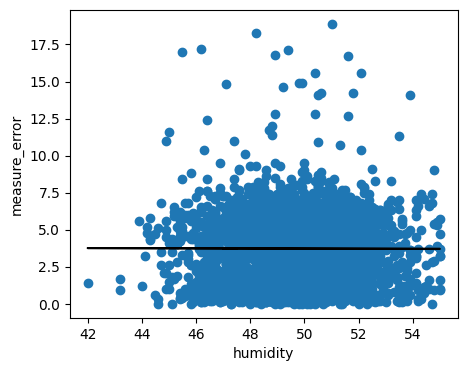

Slope:  [14.78434307]


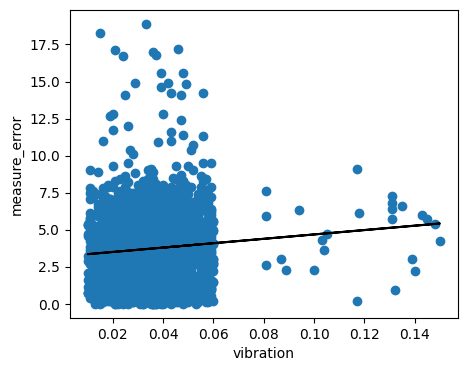

In [59]:
from sklearn.linear_model import LinearRegression

env_factors = data[['exposure_dose', 'temperature', 'humidity', 'vibration']]
y =  data['measure_error'].to_frame()

for f in env_factors:
    x = data[f].to_frame()
    model = LinearRegression().fit(x, y)
    plt.figure(figsize = (5,4))
    plt.scatter(data[f], data['measure_error'])
    plt.plot(x, model.predict(x), 'k')
    print(f'Slope: ',  model.coef_[0])
    plt.xlabel(f)
    plt.ylabel('measure_error')
    plt.show()

In [60]:
from scipy import stats

z_scores = stats.zscore(data['measure_error'])
outliers = data[z_scores> 3]
outliers

,feature_id,timestamp,mask_id,writer_id,x_position,y_position,target_width,measured_width,cd_error,defect_flag,...,humidity,vibration,day,week,month,hour,day_of_week,measure_error,Day,Week
238,F_000239,2026-05-12 13:40:00,M_2026_05_12_05,MBMW_04,3227.4,45.2,60.0,74.1,14.1,1,...,50.5,0.025,12,20,5,13,1,14.1,2026-05-12,20
240,F_000241,2026-05-13 09:00:00,M_2026_05_13_03,MBMW_03,4702.3,4631.0,70.0,81.6,11.6,1,...,45.0,0.043,13,20,5,9,2,11.6,2026-05-13,20
489,F_000490,2026-05-25 10:30:00,M_2026_05_25_03,MBMW_03,4451.3,3380.1,60.0,71.4,11.4,1,...,48.8,0.048,25,22,5,10,0,11.4,2026-05-25,22
561,F_000562,2026-05-27 12:30:00,M_2026_05_27_05,MBMW_03,1064.8,4603.8,70.0,84.2,14.2,1,...,50.6,0.056,27,22,5,12,2,14.2,2026-05-27,22
655,F_000656,2026-06-01 13:10:00,M_2026_06_01_05,MBMW_04,637.9,1171.0,60.0,78.9,18.9,1,...,51.0,0.033,1,23,6,13,0,18.9,2026-06-01,23
786,F_000787,2026-06-08 10:00:00,M_2026_06_08_03,MBMW_03,2917.0,1622.6,80.0,92.4,12.4,1,...,46.4,0.047,8,24,6,10,0,12.4,2026-06-08,24
967,F_000968,2026-06-16 10:10:00,M_2026_06_16_03,MBMW_04,1485.6,2422.7,50.0,64.2,14.2,1,...,51.8,0.043,16,25,6,10,1,14.2,2026-06-16,25
1049,F_001050,2026-06-18 13:50:00,M_2026_06_18_05,MBMW_05,106.3,3136.6,60.0,72.7,12.7,1,...,51.6,0.019,18,25,6,13,3,12.7,2026-06-18,25
1107,F_001108,2026-06-22 13:30:00,M_2026_06_22_05,MBMW_03,3791.2,1936.6,70.0,84.1,14.1,1,...,53.9,0.047,22,26,6,13,0,14.1,2026-06-22,26
1209,F_001210,2026-06-26 10:30:00,M_2026_06_26_03,MBMW_03,4985.6,4902.8,60.0,75.6,15.6,1,...,52.1,0.048,26,26,6,10,4,15.6,2026-06-26,26


In [61]:
data['timestamp'] = pd.to_datetime(data['timestamp'])

In [62]:
data['Day']= data['timestamp'].dt.date
data['Week'] = data['timestamp'].dt.isocalendar().week
daily_error = data.groupby(data['Day'])['measure_error'].mean().reset_index()

In [63]:
daily_error

,Day,measure_error
0,2026-05-01,1.446667
1,2026-05-04,1.346667
2,2026-05-05,1.136667
3,2026-05-06,1.143333
4,2026-05-07,1.493333
...,...,...
81,2026-08-24,6.163333
82,2026-08-25,5.790000
83,2026-08-26,6.080000
84,2026-08-27,6.200000


In [64]:
daily_error['rolling_avg'] = daily_error['measure_error'].rolling(window=5).mean()

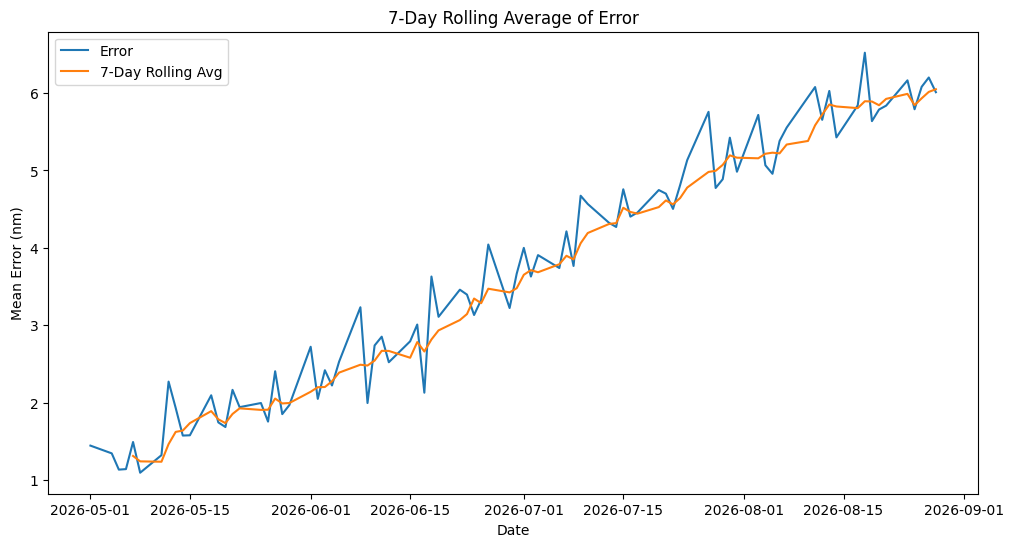

In [65]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_error, x='Day', y='measure_error', label='Error')
sns.lineplot(data=daily_error, x='Day', y='rolling_avg', label='7-Day Rolling Avg')
plt.title('7-Day Rolling Average of Error')
plt.xlabel('Date')
plt.ylabel('Mean Error (nm)')
plt.legend()
plt.show()

In [66]:
coeff = np.polyfit(data['exposure_dose'], data['cd_error'], deg = 2)
model = np.poly1d(coeff)

In [67]:
opt_dose = -coeff[1] / (2*coeff[0])
opt_dose

17.149579587284915

In [68]:
from scipy.optimize import minimize
result = minimize(objective, x0 = 0.1, bounds = [()])

TypeError: 'list' object is not callable